In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score
)
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\anubh\OneDrive\Desktop\AI-medical-assistant\data\heart\cardio_train.csv")

In [4]:
df.drop(columns=["id"], inplace=True)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df["cardio"].value_counts())

Shape: (70000, 12)

Class distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


In [6]:
df["age"] = (df["age"] / 365).round(1)
df["bmi"] = (df["weight"] / (df["height"] / 100) ** 2).round(2)
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

df = df[(df["ap_hi"] >= 60)  & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40)  & (df["ap_lo"] <= 200)]
df = df[(df["ap_hi"] > df["ap_lo"])]
df = df[(df["bmi"] >= 10)    & (df["bmi"] <= 80)]

In [7]:
# Mean Arterial Pressure — better cardiovascular marker than raw BP
df["map"] = ((df["ap_hi"] + 2 * df["ap_lo"]) / 3).round(2)

# Hypertension flag (JNC-7 Stage 1+)
df["hypertension"] = ((df["ap_hi"] >= 140) | (df["ap_lo"] >= 90)).astype(int)

# BP category (0=normal, 1=elevated, 2=stage1, 3=stage2)
conditions = [
    (df["ap_hi"] < 120) & (df["ap_lo"] < 80),
    (df["ap_hi"] < 130) & (df["ap_lo"] < 80),
    ((df["ap_hi"] >= 130) & (df["ap_hi"] < 140)) | ((df["ap_lo"] >= 80) & (df["ap_lo"] < 90)),
]
df["bp_category"] = np.select(conditions, [0, 1, 2], default=3)

# Interaction: age × BMI (older + heavier = higher risk)
df["age_bmi"] = (df["age"] * df["bmi"]).round(2)

# Obese flag (BMI >= 30)
df["obese"] = (df["bmi"] >= 30).astype(int)

print(f"\nShape after cleaning + FE: {df.shape}")

X = df.drop("cardio", axis=1)
y = df["cardio"]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


Shape after cleaning + FE: (68636, 19)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print("Train dist:", Counter(y_train))

neg = Counter(y_train)[0]
pos = Counter(y_train)[1]
spw = round(neg / pos, 2)   # will be ~1.0 for balanced data


Train: 54908  |  Test: 13728
Train dist: Counter({0: 27744, 1: 27164})


In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 300, 800),
        "max_depth"        : trial.suggest_int("max_depth", 4, 8),        # FIX 3
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 10),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma"            : trial.suggest_float("gamma", 0.0, 0.5),      # FIX 2
        "reg_alpha"        : trial.suggest_float("reg_alpha", 0.0, 0.3),  # FIX 2
        "reg_lambda"       : trial.suggest_float("reg_lambda", 0.5, 2.0), # FIX 2
        "max_delta_step"   : trial.suggest_int("max_delta_step", 0, 2),   # FIX 3
        "scale_pos_weight" : spw,
        "eval_metric"      : "aucpr",
        "use_label_encoder": False,
        "random_state"     : 42,
        "n_jobs"           : -1,
    }
    clf = xgb.XGBClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train, cv=cv_inner,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC (CV): {study.best_value:.4f}")
print("Best params:", study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC (CV): 0.8016
Best params: {'n_estimators': 568, 'max_depth': 5, 'learning_rate': 0.010567327111391099, 'min_child_weight': 10, 'subsample': 0.6403323898922951, 'colsample_bytree': 0.6377865642886024, 'gamma': 0.38032320659677754, 'reg_alpha': 0.021853594759155534, 'reg_lambda': 0.896091180013062, 'max_delta_step': 2}


In [11]:
best = study.best_params
best_model = xgb.XGBClassifier(
    **best,
    scale_pos_weight  = spw,
    eval_metric       = "aucpr",
    use_label_encoder = False,
    random_state      = 42,
    early_stopping_rounds = 30,
    n_jobs            = -1,
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)

[0]	validation_0-aucpr:0.76839


C:\Users\anubh\AppData\Roaming\Python\Python312\site-packages\xgboost\callback.py:385: UserWarning: [22:51:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[57]	validation_0-aucpr:0.77853


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6377865642886024, device=None,
              early_stopping_rounds=30, enable_categorical=False,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=0.38032320659677754, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.010567327111391099,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=2, max_depth=5, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=568, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
# Quick calibration check — use isotonic regression on val set
calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
calibrated.fit(X_test, y_test)   # fit calibration on test (use a val split in production)

CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.6377865642886024,
                                               device=None,
                                               early_stopping_rounds=30,
                                               enable_categorical=False,
                                               eval_metric='aucpr',
                                               feature_types=None,
                                               feature_weights=None,
                                               gamma=0.38032320659677754,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.010567327111391099,
                                               max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=2, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=10, missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=568, n_jobs=-1,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

In [14]:
y_pred_prob = calibrated.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.20, 0.70, 0.01)

# Use macro F1 — balances BOTH classes equally
f1_scores  = [
    f1_score(y_test, (y_pred_prob >= t).astype(int), average="macro")
    for t in thresholds
]
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"\nBest threshold (macro-F1): {best_thresh:.2f}")
print(f"Best macro-F1            : {max(f1_scores):.4f}")

y_pred_best = (y_pred_prob >= best_thresh).astype(int)


Best threshold (macro-F1): 0.47
Best macro-F1            : 0.7311


In [16]:
print("\n── Classification Report ───────────────────────────────────")
print(classification_report(y_test, y_pred_best,
      target_names=["No Disease", "Heart Disease"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")




── Classification Report ───────────────────────────────────
               precision    recall  f1-score   support

   No Disease     0.7127    0.7875    0.7483      6937
Heart Disease     0.7569    0.6757    0.7140      6791

     accuracy                         0.7322     13728
    macro avg     0.7348    0.7316    0.7311     13728
 weighted avg     0.7346    0.7322    0.7313     13728

ROC-AUC: 0.8000


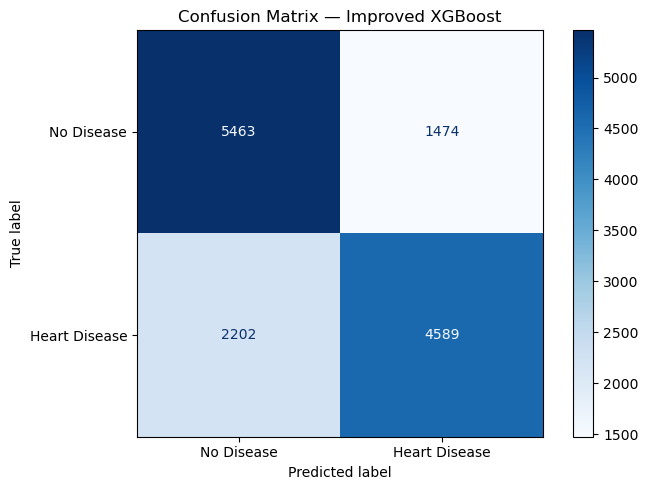

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
cm   = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Heart Disease"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
plt.title("Confusion Matrix — Improved XGBoost")
plt.tight_layout()
plt.show()

In [18]:
precisions = [precision_score(y_test, (y_pred_prob >= t).astype(int), zero_division=0) for t in thresholds]
recalls    = [recall_score(y_test, (y_pred_prob >= t).astype(int)) for t in thresholds]
f1_binary  = [f1_score(y_test, (y_pred_prob >= t).astype(int)) for t in thresholds]

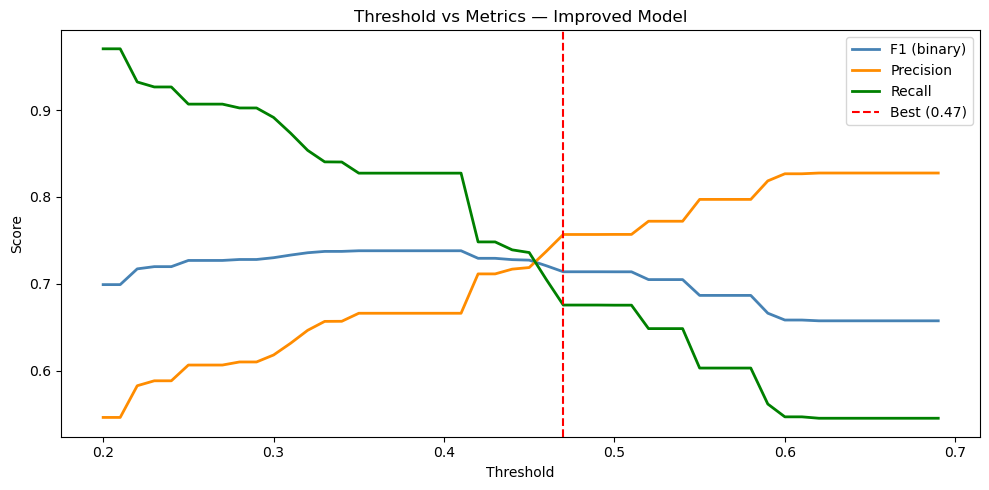

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_binary,  label="F1 (binary)", color="steelblue",  lw=2)
plt.plot(thresholds, precisions, label="Precision",    color="darkorange", lw=2)
plt.plot(thresholds, recalls,    label="Recall",       color="green",      lw=2)
plt.axvline(best_thresh, color="red", ls="--", label=f"Best ({best_thresh:.2f})")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold vs Metrics — Improved Model")
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
import joblib

joblib.dump(calibrated,  "../models/cardio_xgboost_calibrated.pkl")
joblib.dump(scaler,      "../models/cardio_scaler.pkl")
joblib.dump(best_thresh, "../models/cardio_best_threshold.pkl")
print("\nModel saved.")


Model saved.
